# Exact-PaSCient — Performance Analysis

Analysis of the scGPT + LoRA backbone with the parameter-free PaSCient head
(`framework_exact_pascient.py`) on the UC healthy-vs-inflamed binary task.

**Design** (per `train.py` / `data_loader.py`):
- **5 seeds** (`seed_0`…`seed_4`), each = an independent donor-level partition.
- Per seed: stratified **donor-level** hold-out test (`test_size=0.15`) +
  **5-fold `StratifiedGroupKFold`** (grouped by `donor_id`) on the remainder.
- Per-seed test score = **mean-softmax ensemble** of the 5 fold models on that seed's test donors.

This notebook reads only the saved `seed_*/results.json` files — no GPU or data reload needed.

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
    HAS_SNS = True
except Exception:
    plt.style.use("seaborn-v0_8-whitegrid")
    HAS_SNS = False

BASE = "."
OUT  = "analysis_outputs"
os.makedirs(OUT, exist_ok=True)

seed_dirs = sorted(glob.glob(os.path.join(BASE, "seed_*")))
results = {}
for d in seed_dirs:
    sid = int(os.path.basename(d).split("_")[1])
    with open(os.path.join(d, "results.json")) as f:
        results[sid] = json.load(f)
SEEDS = sorted(results)
print(f"Loaded {len(SEEDS)} seeds: {SEEDS}")

Loaded 5 seeds: [0, 1, 2, 3, 4]


## 1. Per-seed ensemble metrics

In [2]:
rows = []
for s in SEEDS:
    m = results[s]["test_metrics"]
    rows.append({
        "seed": s,
        "balanced_accuracy": m["balanced_accuracy"],
        "f1": m["f1"],
        "auc": m["auc"],
        "ensemble": results[s].get("ensemble_method", "?"),
    })
ens_df = pd.DataFrame(rows).set_index("seed")

summary = ens_df[["balanced_accuracy", "f1", "auc"]].agg(["mean", "std", "min", "max"]).T
summary["mean ± std"] = summary.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)

print("Per-seed ensemble test metrics:")
display(ens_df)
print("\nCross-seed summary:")
display(summary[["mean", "std", "min", "max", "mean ± std"]])

ens_df.to_csv(os.path.join(OUT, "per_seed_ensemble_metrics.csv"))
summary.to_csv(os.path.join(OUT, "cross_seed_summary.csv"))

Per-seed ensemble test metrics:


,balanced_accuracy,f1,auc,ensemble
seed,,,,
0,0.864035,0.833333,0.934211,mean_softmax
1,0.712719,0.636364,0.846491,mean_softmax
2,0.958333,0.956522,1.000000,mean_softmax
3,0.894737,0.857143,0.951754,mean_softmax
4,0.833333,0.800000,0.978070,mean_softmax



Cross-seed summary:


,mean,std,min,max,mean ± std
balanced_accuracy,0.852632,0.090862,0.712719,0.958333,0.853 ± 0.091
f1,0.816672,0.116472,0.636364,0.956522,0.817 ± 0.116
auc,0.942105,0.059040,0.846491,1.000000,0.942 ± 0.059


## 2. Per-fold test metrics (within each seed)

In [3]:
fold_rows = []
for s in SEEDS:
    for fi, fm in enumerate(results[s]["test_metrics_per_fold"]):
        fold_rows.append({
            "seed": s, "fold": fi,
            "loss": fm["loss"],
            "balanced_accuracy": fm["balanced_accuracy"],
            "f1": fm["f1"], "auc": fm["auc"],
        })
fold_df = pd.DataFrame(fold_rows)
print("Per-fold test metrics (25 models):")
display(fold_df)

print("\nMean of single-fold models vs ensemble (per seed):")
cmp = fold_df.groupby("seed")[["balanced_accuracy","f1","auc"]].mean()
cmp = cmp.add_suffix("_foldmean").join(ens_df[["balanced_accuracy","f1","auc"]].add_suffix("_ensemble"))
display(cmp)
fold_df.to_csv(os.path.join(OUT, "per_fold_test_metrics.csv"), index=False)

Per-fold test metrics (25 models):


,seed,fold,loss,balanced_accuracy,f1,auc
0,0,0,0.351223,0.837719,0.800000,0.921053
1,0,1,0.443811,0.785088,0.740741,0.872807
2,0,2,0.431356,0.807018,0.761905,0.938596
3,0,3,0.340148,0.890351,0.869565,0.947368
4,0,4,0.424025,0.822368,0.782609,0.942982
5,1,0,0.570024,0.785088,0.740741,0.881579
6,1,1,0.489519,0.660088,0.583333,0.820175
7,1,2,0.696621,0.682018,0.555556,0.855263
8,1,3,0.570802,0.629386,0.500000,0.828947
9,1,4,0.589693,0.712719,0.636364,0.855263



Mean of single-fold models vs ensemble (per seed):


,balanced_accuracy_foldmean,f1_foldmean,auc_foldmean,balanced_accuracy_ensemble,f1_ensemble,auc_ensemble
seed,,,,,,
0,0.828509,0.790964,0.924561,0.864035,0.833333,0.934211
1,0.693860,0.603199,0.848246,0.712719,0.636364,0.846491
2,0.890351,0.869264,0.973684,0.958333,0.956522,1.000000
3,0.802193,0.693997,0.895614,0.894737,0.857143,0.951754
4,0.844737,0.812710,0.959649,0.833333,0.800000,0.978070


## 3. Visualizations

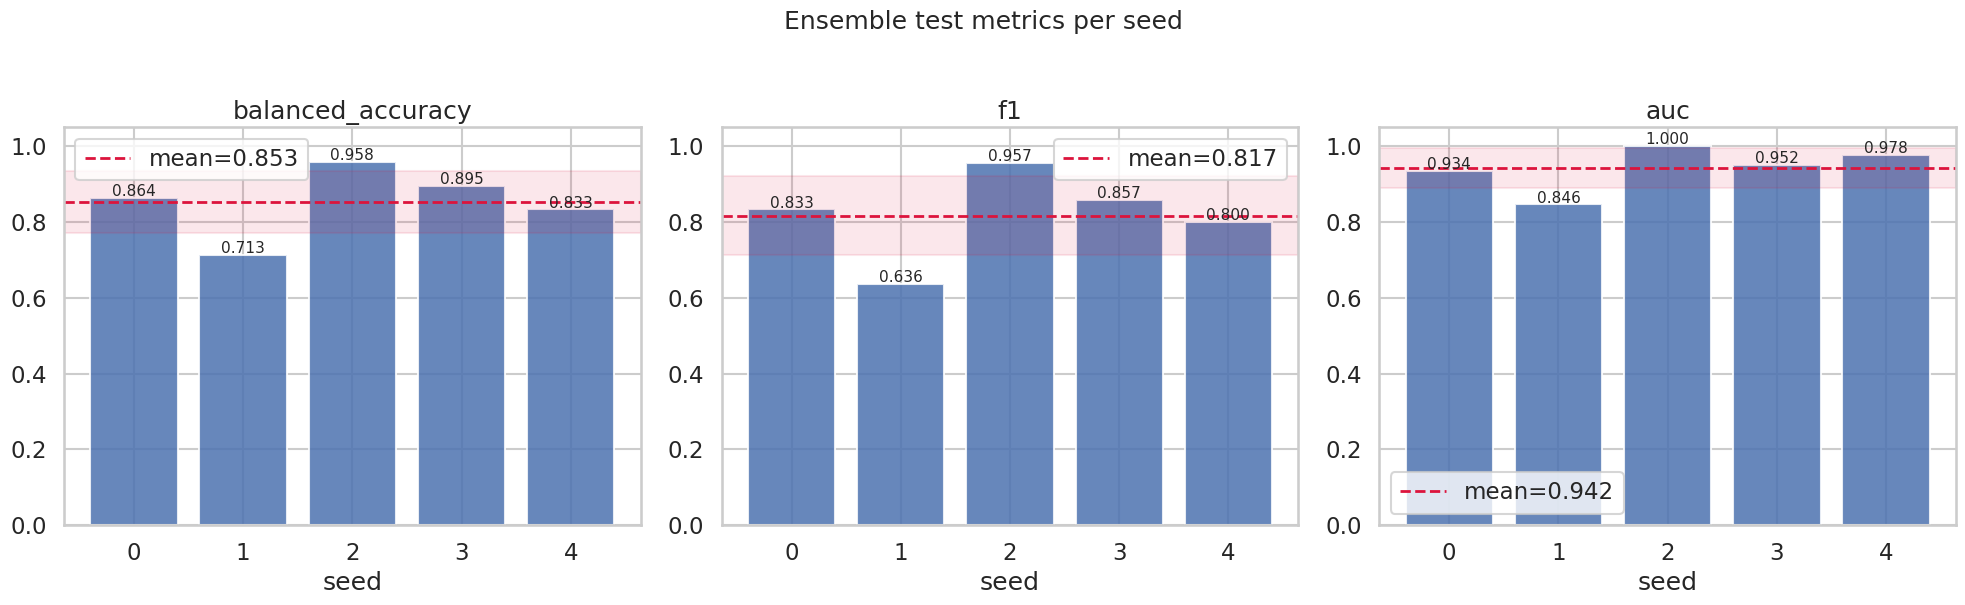

In [4]:
metrics = ["balanced_accuracy", "f1", "auc"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, met in zip(axes, metrics):
    vals = ens_df[met].values
    ax.bar([str(s) for s in SEEDS], vals, color="#4C72B0", alpha=0.85)
    mu, sd = vals.mean(), vals.std()
    ax.axhline(mu, color="crimson", ls="--", lw=2, label=f"mean={mu:.3f}")
    ax.axhspan(mu-sd, mu+sd, color="crimson", alpha=0.10)
    for i, v in enumerate(vals):
        ax.text(i, v+0.005, f"{v:.3f}", ha="center", fontsize=11)
    ax.set_title(met); ax.set_xlabel("seed"); ax.set_ylim(0, 1.05); ax.legend()
fig.suptitle("Ensemble test metrics per seed", y=1.02, fontsize=18)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "ensemble_metrics_per_seed.png"), dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_735816/206338888.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(s) for s in SEEDS], patch_artist=True)
/tmp/ipykernel_735816/206338888.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(s) for s in SEEDS], patch_artist=True)
/tmp/ipykernel_735816/206338888.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[str(s) for s in SEEDS], patch_artist=True)


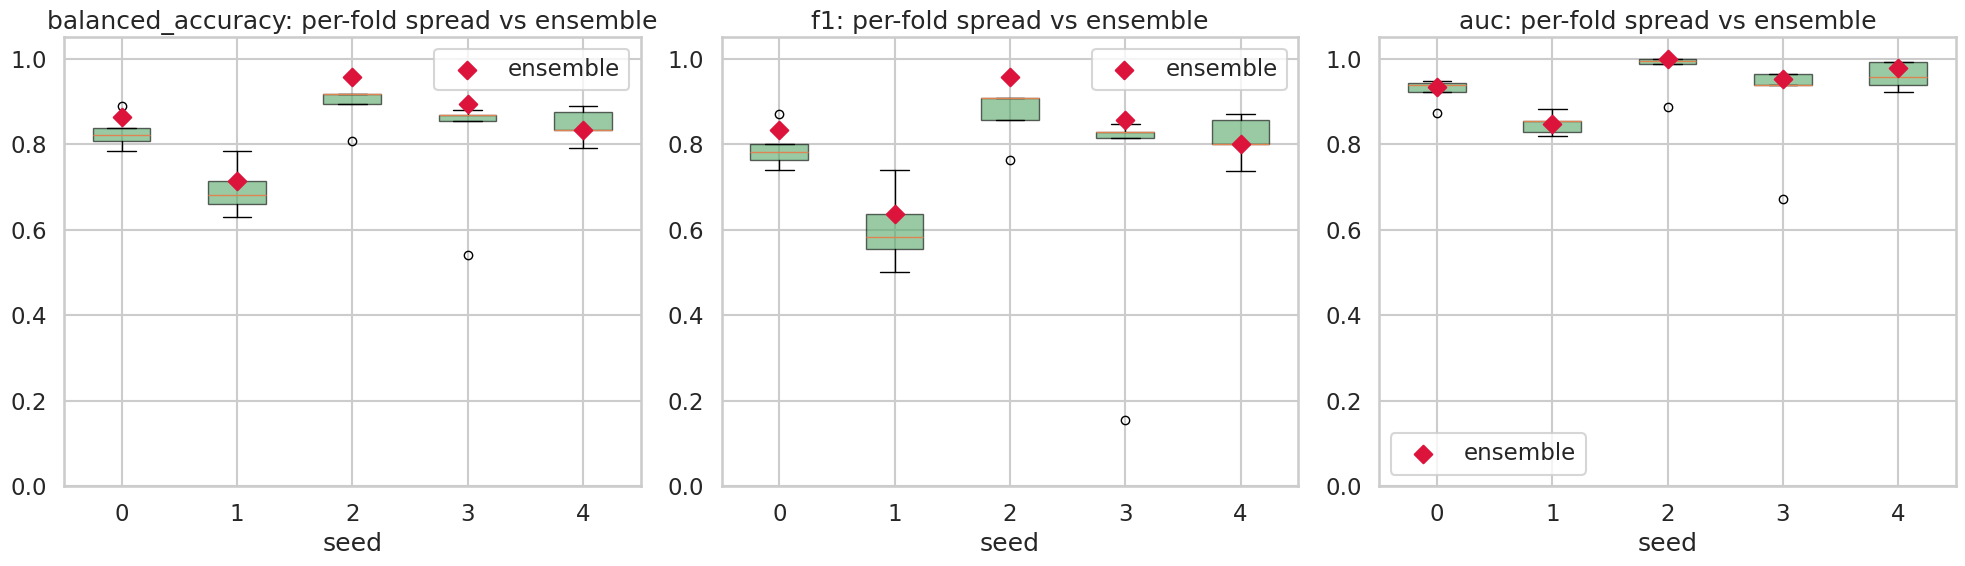

In [5]:
# Distribution of single-fold model performance across all 25 models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, met in zip(axes, metrics):
    data = [fold_df[fold_df.seed==s][met].values for s in SEEDS]
    bp = ax.boxplot(data, labels=[str(s) for s in SEEDS], patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#55A868"); patch.set_alpha(0.6)
    # overlay ensemble value as red diamond
    ax.scatter(range(1, len(SEEDS)+1), ens_df[met].values, color="crimson",
               marker="D", s=80, zorder=5, label="ensemble")
    ax.set_title(f"{met}: per-fold spread vs ensemble"); ax.set_xlabel("seed")
    ax.set_ylim(0, 1.05); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(OUT, "perfold_vs_ensemble.png"), dpi=150, bbox_inches="tight")
plt.show()

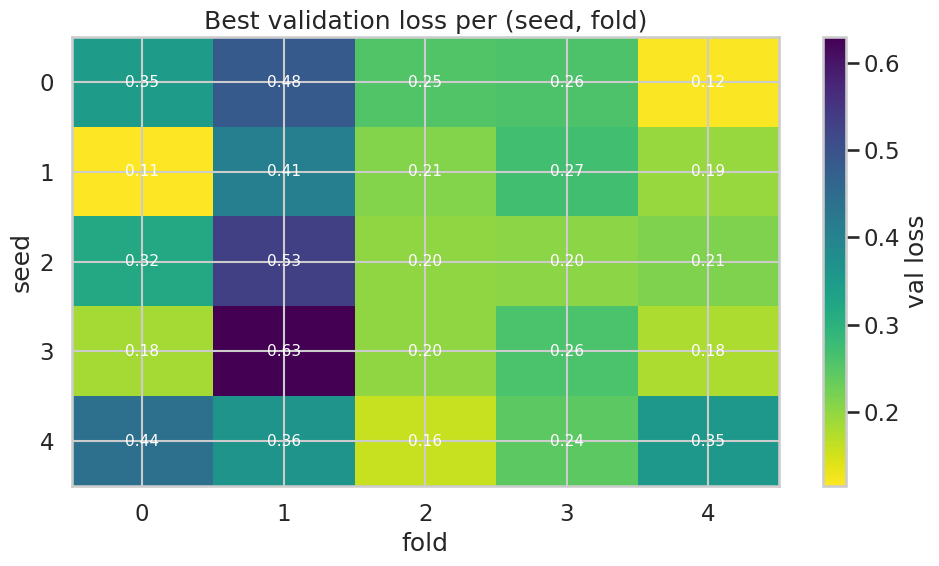

In [6]:
# Validation loss per fold (model-selection signal)
val_rows = []
for s in SEEDS:
    for fi, vl in enumerate(results[s]["fold_val_losses"]):
        val_rows.append({"seed": s, "fold": fi, "val_loss": vl})
val_df = pd.DataFrame(val_rows)
pivot = val_df.pivot(index="seed", columns="fold", values="val_loss")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
ax.set_xlabel("fold"); ax.set_ylabel("seed"); ax.set_title("Best validation loss per (seed, fold)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}", ha="center", va="center",
                color="white", fontsize=11)
fig.colorbar(im, ax=ax, label="val loss")
fig.tight_layout(); fig.savefig(os.path.join(OUT, "val_loss_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Training cost (time & epochs)

,total_hours,total_epochs,per_fold_epochs
seed,,,
0,14.215275,93,"[14, 9, 16, 23, 31]"
1,12.314661,79,"[25, 9, 17, 11, 17]"
2,13.832133,91,"[20, 8, 19, 27, 17]"
3,14.701569,96,"[28, 7, 24, 18, 19]"
4,12.206633,79,"[14, 17, 18, 19, 11]"


Total compute across all seeds: 67.3 GPU-hours


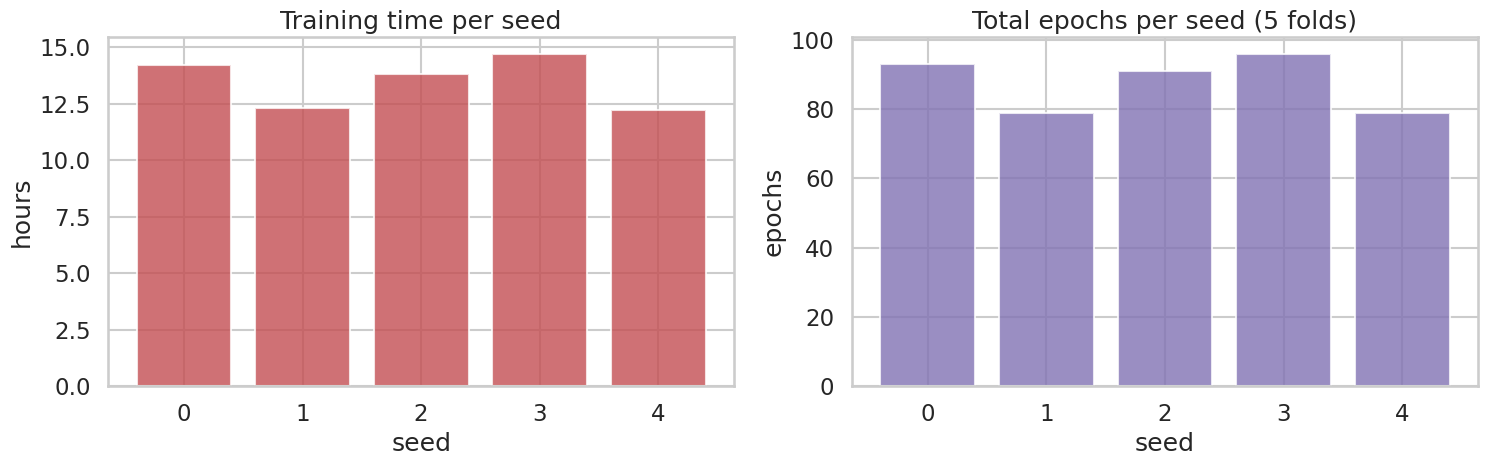

In [7]:
cost_rows = []
for s in SEEDS:
    t = results[s]["timing"]
    cost_rows.append({
        "seed": s,
        "total_hours": t["total_training_time_sec"]/3600,
        "total_epochs": t["total_epochs"],
        "per_fold_epochs": t["per_fold_epochs"],
    })
cost_df = pd.DataFrame(cost_rows).set_index("seed")
display(cost_df)
print(f"Total compute across all seeds: {cost_df['total_hours'].sum():.1f} GPU-hours")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].bar([str(s) for s in SEEDS], cost_df["total_hours"], color="#C44E52", alpha=0.8)
ax[0].set_title("Training time per seed"); ax[0].set_ylabel("hours"); ax[0].set_xlabel("seed")
ax[1].bar([str(s) for s in SEEDS], cost_df["total_epochs"], color="#8172B3", alpha=0.8)
ax[1].set_title("Total epochs per seed (5 folds)"); ax[1].set_ylabel("epochs"); ax[1].set_xlabel("seed")
fig.tight_layout(); fig.savefig(os.path.join(OUT, "training_cost.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Run configuration

In [8]:
cfg = results[SEEDS[0]]["config"]
cfg_df = pd.DataFrame(sorted(cfg.items()), columns=["param", "value"])
display(cfg_df)

# Verify config is identical across seeds (except seed/output_dir)
ignore = {"seed", "output_dir"}
base = {k: v for k, v in cfg.items() if k not in ignore}
for s in SEEDS[1:]:
    other = {k: v for k, v in results[s]["config"].items() if k not in ignore}
    assert other == base, f"Config differs for seed {s}!"
print("✓ Config identical across all seeds (only seed/output_dir differ).")

,param,value
0,bag_col,None
1,checkpoint_path,../scgpt/continual_pretrained/best_model.pt
2,chunk_size,256
3,data_path,../aditya_goel/atlas_concatenated_v2_subset_UC...
4,device,cuda
5,disease_label,Diseased
6,dropout,0.2
7,early_stop_patience,5
8,epochs,100
9,gene_col,gene_col


✓ Config identical across all seeds (only seed/output_dir differ).


## 6. Takeaways

- **Headline:** cross-seed mean ± std for balanced accuracy, F1 and AUC are in the summary table (§1).
- **Stability:** seed variance is driven by the small donor-level test set (~30 donors); inspect §3 boxplots to see how much ensembling tightens single-fold spread.
- **Ensemble benefit:** §2 compares the mean-softmax ensemble against the average single-fold model.
- All tables/figures are saved under `analysis_outputs/`.

## 7. Train+Val vs Test boxplot (matches `reference_plot.png`)

For each seed we reload the 5 fold checkpoints and run **stochastic** inference
(random `max_cells` subsampling, `NUM_ROUNDS_PER_FOLD` rounds per fold) on the
**train+val** patients and the **held-out test** patients. Per-patient softmax
probabilities are averaged across all `5 × NUM_ROUNDS_PER_FOLD` rounds before
computing Balanced Accuracy, F1, AUROC, AUPRC.

Result is cached to `analysis_outputs/train_test_metrics_per_seed.csv` so the
plot can be re-rendered without re-running the GPU work.


In [2]:
# ============================================================
# Train+Val vs Test performance (4 metrics, ensemble over 5 folds × N rounds)
# ============================================================
import sys, gc, time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import scanpy as sc
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score
)

REPO_ROOT = os.path.abspath("../Single-Cell-Metric")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from src.data_loader import DataModule, CustomDataset
from src.framework import SingleCellMetricModel, build_aggregator
from scgpt.tokenizer import GeneVocab

# ---- Config ----
# Each patient is capped at 5k cells (stratified by cell_type). With max_cells_per_patient=2000
# per round, 5 folds × 3 rounds = 15 stochastic passes covers ~99.95% of each patient's 5k cells.
NUM_ROUNDS_PER_FOLD = 3                              # 5 folds × 3 rounds = 15-round avg per seed
DATA_PATH  = "atlas_concatenated_v2_subset_UC_inflamed_baseline_v2_filter_1000_strat5k.h5ad"
MODEL_DIR  = "continual_pretrained"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
CACHE_CSV  = os.path.join(OUT, "train_test_metrics_per_seed_strat5k.csv")
METRICS        = ["balanced_accuracy", "f1", "auroc", "auprc"]
METRIC_LABELS  = {"balanced_accuracy":"Balanced Accuracy", "f1":"F1 Score",
                  "auroc":"AUROC", "auprc":"AUPRC"}

def _compute_metrics(labels, probs):
    preds = probs.argmax(axis=1)
    pos   = probs[:, 1]
    binary = len(np.unique(labels)) > 1
    return {
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "f1":                f1_score(labels, preds, zero_division=0),
        "auroc":             roc_auc_score(labels, pos)            if binary else float("nan"),
        "auprc":             average_precision_score(labels, pos)  if binary else float("nan"),
    }

def _coerce(v):
    if v is None or v == "None":  return None
    if isinstance(v, str) and v.lower() in ("true", "false"): return v.lower() == "true"
    try: return int(v)
    except (TypeError, ValueError): pass
    try: return float(v)
    except (TypeError, ValueError): pass
    return v

# ---- Run inference (skip if cached) ----
if os.path.exists(CACHE_CSV):
    print(f"Loading cached results from {CACHE_CSV} (delete to recompute)")
    res_df = pd.read_csv(CACHE_CSV)
else:
    with open(os.path.join(MODEL_DIR, "args.json")) as f:
        model_config = json.load(f)
    vocab = GeneVocab.from_file(os.path.join(MODEL_DIR, "vocab.json"))
    for tok in ["<pad>", "<cls>", "<eoc>"]:
        if tok not in vocab:
            vocab.append_token(tok)

    base_cfg = {k: _coerce(v) for k, v in results[SEEDS[0]]["config"].items()}

    rows = []
    for seed in SEEDS:
        print(f"\n==== seed {seed} ====")
        adata = sc.read_h5ad(DATA_PATH)
        dm = DataModule(
            adata=adata,
            gene_vocab_file=os.path.join(MODEL_DIR, "vocab.json"),
            gene_col=base_cfg["gene_col"],
            patient_col=base_cfg["patient_col"],
            bag_col=base_cfg["bag_col"],
            label_col=base_cfg["label_col"],
            disease_label=base_cfg["disease_label"],
            max_cells_per_patient=base_cfg["max_cells_per_patient"],
            batch_size=1,
        )
        dm.preprocess_for_scgpt(n_hvg=base_cfg["n_hvg"])
        dm.perform_initial_split(test_size=base_cfg["test_size"], seed=seed)

        # Stochastic-eval datasets (is_training=True → random max_cells subsample each pass)
        subsets = {
            "Train+Val": CustomDataset(
                dm.train_val_adata, dm.vocab,
                label_col=base_cfg["label_col"], disease_label=base_cfg["disease_label"],
                bag_col=dm.bag_col, max_cells=base_cfg["max_cells_per_patient"], is_training=True,
            ),
            "Test": CustomDataset(
                dm.test_adata, dm.vocab,
                label_col=base_cfg["label_col"], disease_label=base_cfg["disease_label"],
                bag_col=dm.bag_col, max_cells=base_cfg["max_cells_per_patient"], is_training=True,
            ),
        }

        for subset_name, ds in subsets.items():
            probs_by_bag  = {}
            labels_by_bag = {}

            for fold_idx in range(base_cfg["n_folds"]):
                aggregator = build_aggregator(
                    emb_size=model_config["embsize"], num_classes=base_cfg["num_classes"],
                    normalize=False,
                )
                model = SingleCellMetricModel(
                    model_config=model_config,
                    checkpoint_path=os.path.join(MODEL_DIR, "best_model.pt"),
                    vocab=vocab,
                    aggregator_plus_classifier=aggregator,
                    lora_r=base_cfg["lora_r"],
                    max_seq_length=base_cfg["max_seq_length"],
                    device=DEVICE,
                )
                ckpt_path = os.path.join(f"seed_{seed}", f"best_model_fold{fold_idx}.pt")
                model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
                model.eval()

                for r in range(NUM_ROUNDS_PER_FOLD):
                    _t0 = time.time()
                    np.random.seed(1_000_000 + 1000 * seed + 100 * fold_idx + r)
                    loader = DataLoader(ds, batch_size=1, shuffle=False)
                    use_amp = DEVICE.startswith("cuda")
                    with torch.no_grad():
                        for batch in loader:
                            with torch.amp.autocast("cuda", enabled=use_amp):
                                preds, _, _ = model(batch, chunk_size=base_cfg["chunk_size"])
                            p   = F.softmax(preds.float(), dim=-1).squeeze(0).cpu().numpy()
                            bag = batch["bag_id"][0]
                            probs_by_bag.setdefault(bag, []).append(p)
                            labels_by_bag[bag] = int(batch["label"].item())
                    _dt = time.time() - _t0
                    print(f"  seed={seed} {subset_name:10s} fold={fold_idx} round={r}  [{_dt:6.1f}s]  @ {time.strftime('%H:%M:%S')}", flush=True)

                del model
                if DEVICE == "cuda": torch.cuda.empty_cache()
                gc.collect()

            bag_order = list(probs_by_bag)
            labels    = np.array([labels_by_bag[b] for b in bag_order])
            mean_probs = np.stack([np.mean(probs_by_bag[b], axis=0) for b in bag_order])
            m = _compute_metrics(labels, mean_probs)
            m.update({
                "seed": seed, "split": subset_name,
                "n_rounds_total": base_cfg["n_folds"] * NUM_ROUNDS_PER_FOLD,
                "n_patients": len(bag_order),
            })
            rows.append(m)

        del dm, adata
        gc.collect()

    res_df = pd.DataFrame(rows)
    res_df.to_csv(CACHE_CSV, index=False)
    print(f"Saved → {CACHE_CSV}")

display(res_df)

# ---- Plot: 4-panel boxplot Train+Val vs Test ----
total_rounds = int(res_df["n_rounds_total"].iloc[0])
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
palette = {"Train+Val": "#F2A93B", "Test": "#7AA6C9"}

for ax, met in zip(axes, METRICS):
    pivot = res_df.pivot(index="seed", columns="split", values=met)
    splits = ["Train+Val", "Test"]
    data = [pivot[s].values for s in splits]
    bp = ax.boxplot(data, labels=["Train", "Test"], patch_artist=True, widths=0.55)
    for patch, s in zip(bp["boxes"], splits):
        patch.set_facecolor(palette[s]); patch.set_alpha(0.55); patch.set_edgecolor("#444")
    for med in bp["medians"]:
        med.set_color("#222"); med.set_linewidth(1.6)
    rng = np.random.default_rng(0)
    for i, s in enumerate(splits, start=1):
        vals = pivot[s].values
        x = np.full_like(vals, i, dtype=float) + rng.uniform(-0.06, 0.06, len(vals))
        ax.scatter(x, vals, color=palette[s], edgecolor="#444", s=40, zorder=5)
    tr, te = pivot["Train+Val"].mean(), pivot["Test"].mean()
    ax.set_title(
        f"{METRIC_LABELS[met]}\nTrain: {tr:.3f}  Test: {te:.3f}  (Δ={tr - te:+.3f})",
        fontsize=12,
    )
    ax.set_ylabel(METRIC_LABELS[met])
    ax.grid(True, alpha=0.3)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=palette["Train+Val"], alpha=0.55, ec="#444"),
    plt.Rectangle((0, 0), 1, 1, facecolor=palette["Test"],      alpha=0.55, ec="#444"),
]
fig.legend(handles, ["Train+Val", "Test"], loc="upper right",
           bbox_to_anchor=(0.995, 1.02), frameon=False)
fig.suptitle(
    f"Train+Val vs Test Performance ({len(SEEDS)} Seeds, {total_rounds}-Round Avg)",
    fontsize=14, y=1.05, fontweight="bold",
)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "train_vs_test_performance_strat5k.png"), dpi=150, bbox_inches="tight")
plt.show()


/home/sagemaker-user/user-default-efs/envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/sagemaker-user/user-default-efs/envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/sagemaker-user/user-default-efs/envs/scgpt/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/sagemaker-user/user-default-efs/envs/scgpt/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TO


==== seed 0 ====


INFO:scGPT_DataEngine:bag_col and patient_col are the same column — each bag corresponds to one donor.


INFO:scGPT_DataEngine:Starting scGPT Preprocessing...


INFO:scGPT_DataEngine:Gene set reduced to 4396 genes based on scGPT vocabulary.


...

  seed=1 Train+Val  fold=3 round=1  [2149.7s]  @ 06:51:06


  seed=1 Train+Val  fold=3 round=2  [2150.6s]  @ 07:26:57


Loading weights from continual_pretrained/best_model.pt...


  seed=1 Train+Val  fold=4 round=0  [2136.8s]  @ 08:02:35


  seed=1 Train+Val  fold=4 round=1  [2138.0s]  @ 08:38:13
